# 📈 The Mathematics of Adstock (Carryover)

> **A math-first tour of how `mmm_framework` represents the *carryover* of marketing.**
> This is notebook **01** in the math series. We derive the equations, plot every kernel, and
> verify each formula against the **actual framework code** with `assert` statements — so "the
> notebook runs clean" *means* "the math is right."

When you spend on advertising in week $t$, the effect does not vanish in week $t$. A TV flight seen
this week still nudges a purchase three weeks from now; a brand campaign builds for a while *before*
it peaks. **Adstock** (a.k.a. *carryover* or the *retention* transform) is the function that turns a
raw spend series $x_t$ into an *effective* exposure series $y_t$ that carries the past forward.

The framework offers **three related representations** of adstock, plus a fourth thing that is easy to
misread — the way the **default model actually uses it**. We cover all four:

| | Representation | Where | Estimated? |
|---|---|---|---|
| **(a)** | Geometric **recurrence** (IIR) | `transforms.geometric_adstock` | fixed $\alpha$ |
| **(b)** | Normalized **FIR kernels** (geometric / delayed / Weibull) | `transforms.adstock.adstock_weights` + `apply_adstock` | fixed shape |
| **(c)** | **In-graph PyTensor** mirror of (b) | `transforms.adstock_pt` | differentiable, learned |
| **(d)** | The **default `BayesianMMM`** mechanism | `model.base` | learns a *blend weight*, **not** a decay rate |

We close with the **identifiability** catch that makes all of this subtle in practice.

In [1]:
import warnings, sys
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from aurora import PALETTE, CHANNEL_COLORS   # brand colors for visual consistency
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.2),
    "axes.grid": True, "grid.alpha": 0.18,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfc7bd", "axes.titleweight": "bold",
    "figure.facecolor": "white", "savefig.facecolor": "white", "font.size": 10,
})
ACCENT, INK, MUTED = PALETTE["accent"], PALETTE["ink"], PALETTE["muted"]

We pull the real transforms straight from the framework — every plot and assertion below calls these
exact functions, not re-implementations.

In [2]:
from mmm_framework.transforms import geometric_adstock, geometric_adstock_2d
from mmm_framework.transforms.adstock import adstock_weights, apply_adstock, parametric_adstock

# A unit impulse: 1 unit of spend at t=0, nothing after. The cleanest probe of any
# linear carryover system — its response *is* the kernel.
T = 24
impulse = np.zeros(T); impulse[0] = 1.0
ALPHAS = [0.2, 0.5, 0.8]
print("loaded:", geometric_adstock.__name__, adstock_weights.__name__,
      apply_adstock.__name__, parametric_adstock.__name__)

loaded: geometric_adstock adstock_weights apply_adstock parametric_adstock


## (a) Geometric adstock as a recurrence (IIR)

The classic form is a one-line **recurrence** — an *infinite impulse response* (IIR) filter:

$$
y_t \;=\; x_t \;+\; \alpha\, y_{t-1},
\qquad y_0 = x_0,
\qquad \alpha \in [0, 1).
$$

This is exactly what `geometric_adstock(x, alpha)` computes. The decay rate $\alpha$ is the share of
*last* week's effective exposure that survives into *this* week. $\alpha = 0$ means no carryover (the
transform is the identity); $\alpha \to 1$ means the effect barely fades.

### Unrolling it: where do the lag weights come from?

Substitute the recurrence into itself. Starting from $y_0 = x_0$:

$$
\begin{aligned}
y_1 &= x_1 + \alpha x_0,\\
y_2 &= x_2 + \alpha x_1 + \alpha^2 x_0,\\
&\;\;\vdots\\
y_t &= \sum_{k=0}^{t} \alpha^{k}\, x_{t-k}.
\end{aligned}
$$

So the recurrence is *secretly* a convolution with geometrically-decaying weights $w_k = \alpha^k$. A
**unit impulse** at $t=0$ therefore produces the sequence $1,\, \alpha,\, \alpha^2,\, \alpha^3,\dots$ —
the weights are literally readable off the output.

### The total carryover multiplier

Summing the weights over all lags is a geometric series:

$$
\sum_{k=0}^{\infty} \alpha^{k} \;=\; \frac{1}{1-\alpha}.
$$

This is the framework docstring's claim that *"the total effect of a unit spend is scaled by
$1/(1-\alpha)$."* At $\alpha = 0.5$ a single dollar of spend contributes the equivalent of **two**
dollars of effective exposure once you add up all its future echoes. Crucially this kernel is
**un-normalized**: its weights sum to $1/(1-\alpha) > 1$, not to $1$. Hold that thought for part (b).

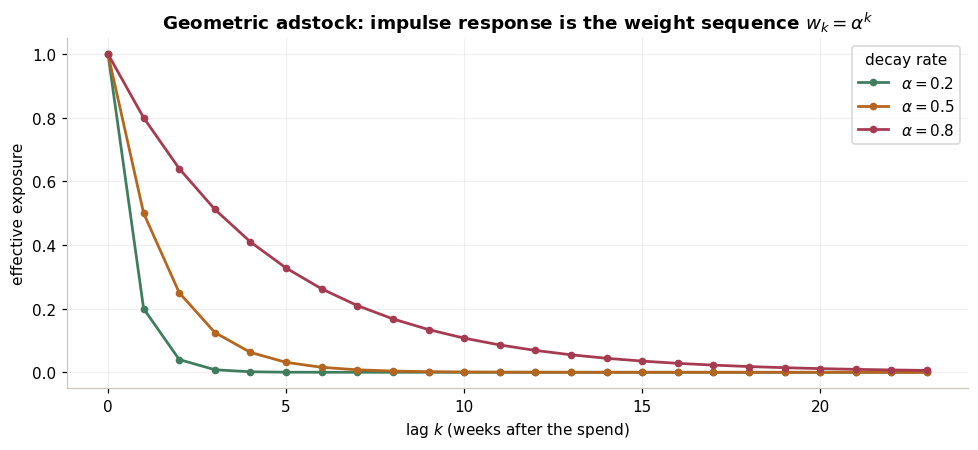

In [3]:
# Impulse responses at several alphas — the geometric decay made visible.
fig, ax = plt.subplots()
colors = [PALETTE["leaf"], ACCENT, PALETTE["berry"]]
for a, col in zip(ALPHAS, colors):
    y = geometric_adstock(impulse, a)
    ax.plot(np.arange(T), y, "-o", ms=4, color=col, lw=1.8, label=rf"$\alpha={a}$")
ax.set_xlabel("lag $k$ (weeks after the spend)")
ax.set_ylabel("effective exposure")
ax.set_title("Geometric adstock: impulse response is the weight sequence $w_k=\\alpha^k$")
ax.legend(title="decay rate")
plt.tight_layout(); plt.show()

In [4]:
# VERIFY (a): unit-impulse response equals alpha**k, and its sum -> 1/(1-alpha).
# Use a long series so the truncated geometric series is accurate even at alpha=0.8.
Tlong = 200
imp_long = np.zeros(Tlong); imp_long[0] = 1.0
for a in ALPHAS:
    y = geometric_adstock(imp_long, a)
    expected_weights = a ** np.arange(Tlong)
    assert np.allclose(y, expected_weights, atol=1e-9), f"weights mismatch at alpha={a}"
    assert np.isclose(y.sum(), 1.0 / (1.0 - a), atol=1e-3), f"sum mismatch at alpha={a}"
print("✓ geometric_adstock(impulse) == alpha**k for all alpha")
print("✓ sum of weights == 1/(1-alpha):",
      {a: round(1/(1-a), 3) for a in ALPHAS})

✓ geometric_adstock(impulse) == alpha**k for all alpha
✓ sum of weights == 1/(1-alpha): {0.2: 1.25, 0.5: 2.0, 0.8: 5.0}


The $1/(1-\alpha)$ multiplier *explodes* as $\alpha \to 1$ — which is why $\alpha$ is constrained to
$[0,1)$ and why a model that estimates $\alpha$ near the boundary is a red flag (infinite memory).

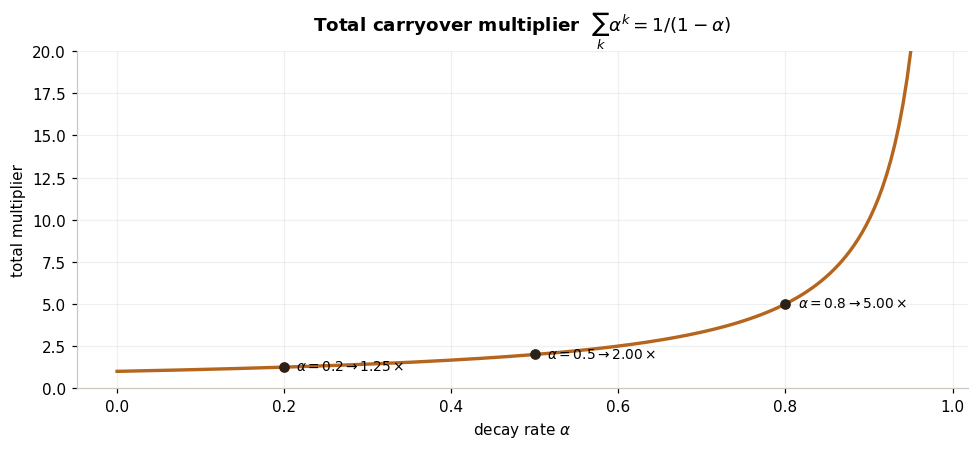

In [5]:
fig, ax = plt.subplots()
a_grid = np.linspace(0, 0.97, 200)
ax.plot(a_grid, 1.0 / (1.0 - a_grid), color=ACCENT, lw=2.2)
for a in ALPHAS:
    ax.plot(a, 1/(1-a), "o", color=INK, ms=6)
    ax.annotate(rf"$\alpha={a}\to{1/(1-a):.2f}\times$", (a, 1/(1-a)),
                textcoords="offset points", xytext=(8, -2), fontsize=9)
ax.set_xlabel(r"decay rate $\alpha$")
ax.set_ylabel("total multiplier")
ax.set_title("Total carryover multiplier  $\\sum_k \\alpha^k = 1/(1-\\alpha)$")
ax.set_ylim(0, 20)
plt.tight_layout(); plt.show()

`geometric_adstock_2d(X, alpha)` simply applies the same recurrence independently to each column
(channel) of a $(T, n_\text{channels})$ matrix — handy for adstocking a whole media plan at once. It
is the workhorse the default model precomputes with (part d).

In [6]:
# geometric_adstock_2d applies the 1D recurrence column-wise.
X = np.column_stack([impulse, np.r_[0, 0, 1.0, np.zeros(T - 3)]])  # impulse at t=0 and t=2
Y = geometric_adstock_2d(X, alpha=0.6)
assert Y.shape == X.shape
assert np.allclose(Y[:, 0], geometric_adstock(X[:, 0], 0.6))
assert np.allclose(Y[:, 1], geometric_adstock(X[:, 1], 0.6))
print("✓ geometric_adstock_2d == per-column geometric_adstock   shape:", Y.shape)

✓ geometric_adstock_2d == per-column geometric_adstock   shape: (24, 2)


## (b) Finite-impulse-response (FIR) kernels: geometric, delayed, Weibull

The recurrence in (a) has *infinite* memory and can only ever **peak at lag 0** (the current period is
always the largest). Many media — TV, video, OOH, brand campaigns — instead build for a few weeks and
peak *later*. The framework's `adstock_weights(kind, l_max, ...)` builds an explicit **finite**
weight vector $w = (w_0, w_1, \dots, w_{L-1})$ of length `l_max`, and `apply_adstock(x, w)` performs
the **causal convolution**

$$
y_t \;=\; \sum_{k=0}^{L-1} w_k\, x_{t-k},
$$

with **zero left-padding** (weeks before the series start count as $0$). By construction $w_0$ weights
the *current* period. The wrapper `parametric_adstock(x, kind, l_max=8, ...)` does both steps at once.

Three kernel **shapes** are available:

**Geometric** — $w_k = \alpha^k$. Same shape as (a) but truncated to $L$ lags. Peak at lag $0$.

**Delayed geometric** (Jin et al., 2017) — $w_k = \alpha^{(k-\theta)^2}$. The squared term moves the
peak to lag $\theta$: the weight is maximal where $(k-\theta)^2$ is smallest. Setting $\theta = 0$ puts
the peak back at lag $0$ (like geometric), though the weights are then $\alpha^{k^2}$ — they decay
*faster* than the geometric $\alpha^k$, so it is not literally the geometric kernel, only the same
peak location. This is the kernel that can model a genuinely **delayed peak**.

**Weibull** (PDF form, lags shifted by $1$ so lag $0$ is well-defined for every shape):

$$
w_k \;\propto\; \frac{s}{\lambda}\!\left(\frac{k+1}{\lambda}\right)^{\,s-1}
\exp\!\left[-\left(\frac{k+1}{\lambda}\right)^{s}\right],
$$

with **shape** $s$ (`shape`) and **scale** $\lambda$ (`scale`). The shape governs the silhouette:
$s<1$ **front-loads** (most mass at lag 0, then a long thin tail), $s=1$ is **exponential**, and
$s>1$ pushes the **peak out to a later lag**.

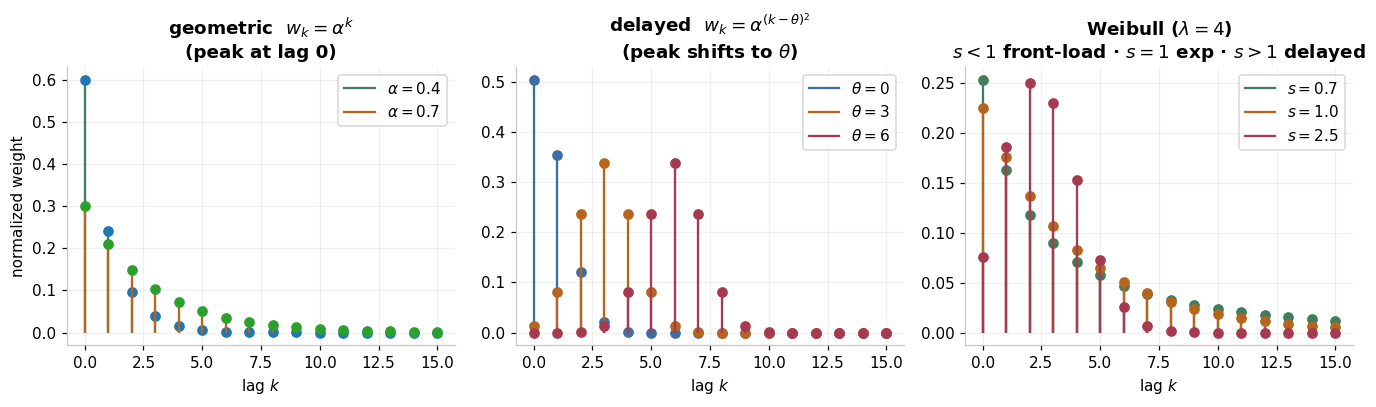

In [7]:
# Kernel weight stems: geometric vs delayed (a few theta) vs Weibull (a few shapes).
L = 16
lags = np.arange(L)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8), sharey=False)

# Geometric — peak at lag 0.
axG = axes[0]
for a, col in zip([0.4, 0.7], [PALETTE["leaf"], ACCENT]):
    w = adstock_weights("geometric", L, alpha=a, normalize=True)
    axG.stem(lags, w, linefmt="-", markerfmt="o", basefmt=" ")
    axG.plot([], [], color=col, label=rf"$\alpha={a}$")
    axG.lines[-2].set_color(col); axG.collections[-1].set_color(col)
axG.set_title("geometric  $w_k=\\alpha^k$\n(peak at lag 0)")
axG.set_xlabel("lag $k$"); axG.set_ylabel("normalized weight"); axG.legend()

# Delayed — peak moves to theta.
axD = axes[1]
for th, col in zip([0, 3, 6], [PALETTE["sky"], ACCENT, PALETTE["berry"]]):
    w = adstock_weights("delayed", L, alpha=0.7, theta=th, normalize=True)
    ml, sl, bl = axD.stem(lags, w, linefmt="-", markerfmt="o", basefmt=" ")
    ml.set_color(col); sl.set_color(col)
    axD.plot([], [], color=col, label=rf"$\theta={th}$")
axD.set_title(r"delayed  $w_k=\alpha^{(k-\theta)^2}$" + "\n(peak shifts to $\\theta$)")
axD.set_xlabel("lag $k$"); axD.legend()

# Weibull — shape controls front-load vs delayed peak.
axW = axes[2]
for s, col in zip([0.7, 1.0, 2.5], [PALETTE["leaf"], ACCENT, PALETTE["berry"]]):
    w = adstock_weights("weibull", L, shape=s, scale=4.0, normalize=True)
    ml, sl, bl = axW.stem(lags, w, linefmt="-", markerfmt="o", basefmt=" ")
    ml.set_color(col); sl.set_color(col)
    axW.plot([], [], color=col, label=rf"$s={s}$")
axW.set_title(r"Weibull ($\lambda=4$)" + "\n$s<1$ front-load · $s=1$ exp · $s>1$ delayed")
axW.set_xlabel("lag $k$"); axW.legend()

plt.tight_layout(); plt.show()

The middle panel is the payoff: as $\theta$ increases the delayed kernel's mass **walks to the right**,
peaking exactly at lag $\theta$. The right panel shows the Weibull's silhouette flipping from a sharp
front-load ($s=0.7$) through an exponential ($s=1$) to a smooth delayed hump ($s=2.5$).

In [8]:
# VERIFY (b): normalization, peak locations, and the equivalence to (a).
L = 16

# 1) normalize=True => weights sum to 1.
for a in ALPHAS:
    assert np.isclose(adstock_weights("geometric", L, alpha=a, normalize=True).sum(), 1.0)

# 2) normalize=False geometric kernel == [a**0, a**1, ...] applied to an impulse.
a = 0.6
imp = np.zeros(L); imp[0] = 1.0
raw_w = adstock_weights("geometric", L, alpha=a, normalize=False)
out = apply_adstock(imp, raw_w)
assert np.allclose(out, a ** np.arange(L), atol=1e-9)

# 3) parametric_adstock(...) == apply_adstock(x, adstock_weights(...)) (it's the wrapper).
x = np.random.default_rng(0).gamma(2.0, 1.0, size=40)
lhs = parametric_adstock(x, "geometric", L, alpha=a, normalize=True)
rhs = apply_adstock(x, adstock_weights("geometric", L, alpha=a, normalize=True))
assert np.allclose(lhs, rhs, atol=1e-12)

# 4) peak locations: geometric argmax == 0; delayed argmax ~= theta (integer theta -> exact).
assert adstock_weights("geometric", L, alpha=a).argmax() == 0
for th in [0, 3, 6]:
    peak = adstock_weights("delayed", L, alpha=0.7, theta=th).argmax()
    assert peak == th, f"delayed peak {peak} != theta {th}"

print("✓ normalize=True -> weights sum to 1")
print("✓ normalize=False geometric kernel == alpha**k on an impulse")
print("✓ parametric_adstock == apply_adstock(x, adstock_weights(...))")
print("✓ geometric argmax == 0 ; delayed argmax == theta")

✓ normalize=True -> weights sum to 1
✓ normalize=False geometric kernel == alpha**k on an impulse
✓ parametric_adstock == apply_adstock(x, adstock_weights(...))
✓ geometric argmax == 0 ; delayed argmax == theta


### `normalize=True` vs `normalize=False` — a magnitude convention, not a shape change

This is the conceptual hinge between (a) and (b). The *shape* of a geometric kernel is the same either
way; what differs is **where the total magnitude lives**.

- **`normalize=False`** keeps the raw weights $w_k = \alpha^k$. They sum to $1/(1-\alpha) > 1$ — exactly
  the IIR multiplier from part (a). The carryover *magnitude* is **inside the kernel**.
- **`normalize=True`** rescales to $\tilde w_k = w_k / \sum_j w_j$, so the weights sum to **$1$**. The
  kernel becomes a **weighted moving average** that only redistributes spend across time; the total
  magnitude is **folded into the channel coefficient $\beta$** downstream.

So normalized-FIR (sum $1$) and the IIR recurrence (sum $1/(1-\alpha)$) are the *same decay shape under
two different magnitude conventions*. Normalizing is the standard MMM choice because it cleanly
separates **timing** (the kernel) from **size** (the coefficient) — but, as we'll see, that separation
is exactly what creates the identifiability headache.

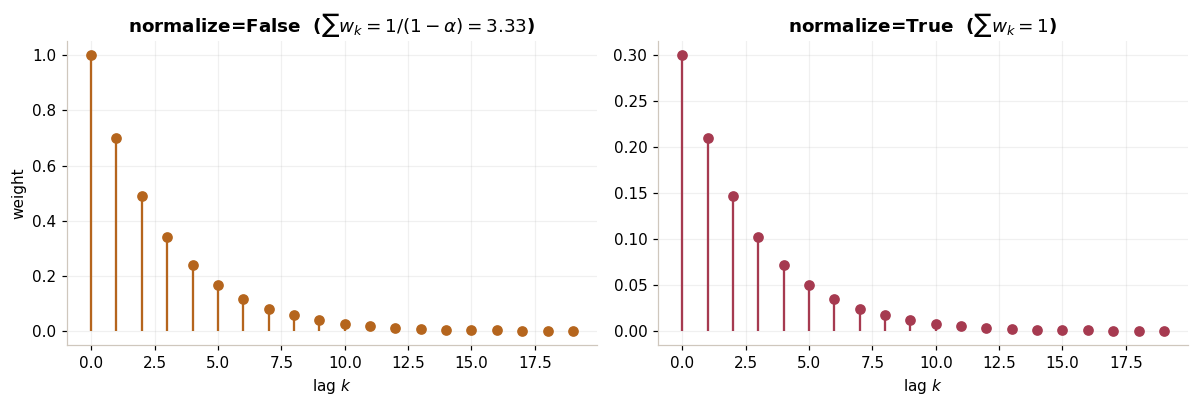

raw sum  = 3.331  (== 1/(1-alpha) = 3.333)
norm sum = 1.000
ratio of the two kernels is constant (identical shape): True


In [9]:
# Effect of normalize: same shape, different total area.
L = 20
lags = np.arange(L)
a = 0.7
w_raw = adstock_weights("geometric", L, alpha=a, normalize=False)
w_nrm = adstock_weights("geometric", L, alpha=a, normalize=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
ax1.stem(lags, w_raw, linefmt="-", markerfmt="o", basefmt=" ")
for ln in ax1.get_lines(): ln.set_color(ACCENT)
ax1.collections[0].set_color(ACCENT)
ax1.set_title(rf"normalize=False  ($\sum w_k = 1/(1-\alpha) = {1/(1-a):.2f}$)")
ax1.set_xlabel("lag $k$"); ax1.set_ylabel("weight")

ax2.stem(lags, w_nrm, linefmt="-", markerfmt="o", basefmt=" ")
for ln in ax2.get_lines(): ln.set_color(PALETTE["berry"])
ax2.collections[0].set_color(PALETTE["berry"])
ax2.set_title(r"normalize=True  ($\sum w_k = 1$)")
ax2.set_xlabel("lag $k$")
plt.tight_layout(); plt.show()

print(f"raw sum  = {w_raw.sum():.3f}  (== 1/(1-alpha) = {1/(1-a):.3f})")
print(f"norm sum = {w_nrm.sum():.3f}")
print("ratio of the two kernels is constant (identical shape):",
      np.allclose(w_raw / w_raw.sum(), w_nrm, atol=1e-12))

### Carryover on a realistic spend series

Real media spend is **bursty** — flights of activity separated by dark periods. Adstock smears each
burst forward in time. Here is a synthetic weekly plan adstocked with a *normalized* geometric kernel
at a low vs a high decay rate: the high-$\alpha$ channel keeps "glowing" long after each flight ends.

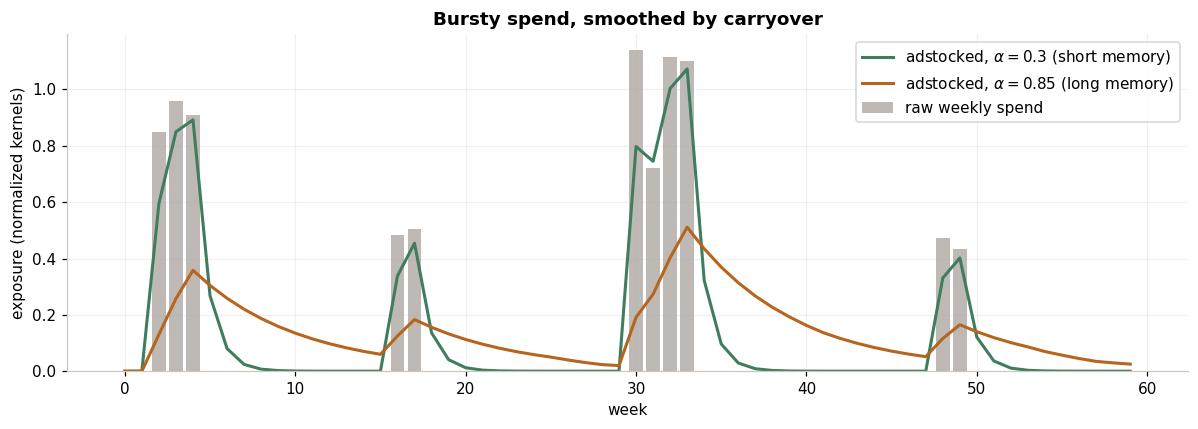

In [10]:
rng = np.random.default_rng(7)
T = 60
spend = np.zeros(T)
# A few flights (bursts) of spend.
for start, length, level in [(2, 3, 1.0), (16, 2, 0.7), (30, 4, 1.2), (48, 2, 0.6)]:
    spend[start:start + length] = level * (0.6 + 0.4 * rng.random(length))

L = 24
y_low = parametric_adstock(spend, "geometric", L, alpha=0.3, normalize=True)
y_high = parametric_adstock(spend, "geometric", L, alpha=0.85, normalize=True)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(np.arange(T), spend, color=MUTED, alpha=0.55, label="raw weekly spend")
ax.plot(np.arange(T), y_low, color=PALETTE["leaf"], lw=2,
        label=r"adstocked, $\alpha=0.3$ (short memory)")
ax.plot(np.arange(T), y_high, color=ACCENT, lw=2,
        label=r"adstocked, $\alpha=0.85$ (long memory)")
ax.set_xlabel("week"); ax.set_ylabel("exposure (normalized kernels)")
ax.set_title("Bursty spend, smoothed by carryover")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

## (c) The in-graph PyTensor mirror

For Bayesian *estimation* we need the kernel to be **differentiable**, so the sampler can learn
$\alpha$, $\theta$, or $(s,\lambda)$ from the data. The module `mmm_framework.transforms.adstock_pt`
provides `adstock_weights_pt`, `apply_adstock_pt`, and `parametric_adstock_pt` — a PyTensor mirror of
the NumPy functions in (b), computing the *same* kernels symbolically.

We won't build a sampler graph here; just note the contract: **the math in (b) is exactly the math
that runs inside the model** when you set `ModelConfig.use_parametric_adstock=True`. The NumPy versions
in this notebook are the reference implementation you can reason about on paper; the PyTensor versions
are the same equations made estimable. The framework even reuses the closure at predict time so a
perturbed spend can be re-adstocked with the *same* learned kernel (used for marginal-ROAS analysis).

In [11]:
# The PyTensor mirror exists and exposes the same three-function API as (b).
from mmm_framework.transforms.adstock_pt import (
    adstock_weights_pt, apply_adstock_pt, parametric_adstock_pt,
)
print("in-graph adstock API:",
      adstock_weights_pt.__name__, apply_adstock_pt.__name__, parametric_adstock_pt.__name__)
print("-> same geometric / delayed / Weibull kernels as (b), differentiable for NUTS.")

in-graph adstock API: adstock_weights_pt apply_adstock_pt parametric_adstock_pt
-> same geometric / delayed / Weibull kernels as (b), differentiable for NUTS.


## (d) How the **default** `BayesianMMM` uses adstock — read this carefully

Here is the single most common point of confusion. **By default** (`use_parametric_adstock=False`) the
model does **not** estimate a decay rate at all. Instead it:

1. **Precomputes** geometric adstock at two *fixed* decay rates — a **low** $\alpha_\text{low}$ and a
   **high** $\alpha_\text{high}$ (from `adstock_alphas`, whose defaults are
   $[0.0,\,0.3,\,0.5,\,0.7,\,0.9]$, so $\alpha_\text{low}=0$ = *no carryover* and
   $\alpha_\text{high}=0.9$ = *strong carryover*), giving two exposure series $x^\text{low}$ and
   $x^\text{high}$ per channel.
2. **Learns a blend weight** per channel, $m \sim \text{Beta}(2,2)$ (the model variable is named
   `adstock_<CHANNEL>`), and mixes the two precomputed series:

$$
x^{\text{adstock}} \;=\; (1-m)\,x^{\text{low}} \;+\; m\,x^{\text{high}},
\qquad m \in (0,1).
$$

So **`adstock_<CHANNEL>` is a mixing weight between two fixed-$\alpha$ geometric adstocks — it is *not*
a decay rate.** $m \to 0$ pins the channel to the short-memory series, $m \to 1$ to the long-memory
series, and intermediate $m$ interpolates. This is cheap (no per-draw recurrence) and well-behaved for
the sampler. The $\text{Beta}(2,2)$ prior is symmetric and gently concentrated toward $m=0.5$.

The **parametric path** (part c) is the alternative: set `use_parametric_adstock=True` and the model
estimates the actual kernel parameters in-graph —
$\alpha$ (`adstock_alpha_<CHANNEL>` $\sim \text{Beta}(2,2)$) for geometric/delayed,
plus $\theta$ (`adstock_theta_<CHANNEL>` $\sim \text{HalfNormal}$) for delayed, or
$(s,\lambda)$ (`adstock_shape/scale_<CHANNEL>` $\sim \text{Gamma}$) for Weibull. Both are legitimate;
they answer different questions. The blend is *"how much memory, on a 2-point scale?"*; the parametric
path is *"what is the precise decay shape?"*

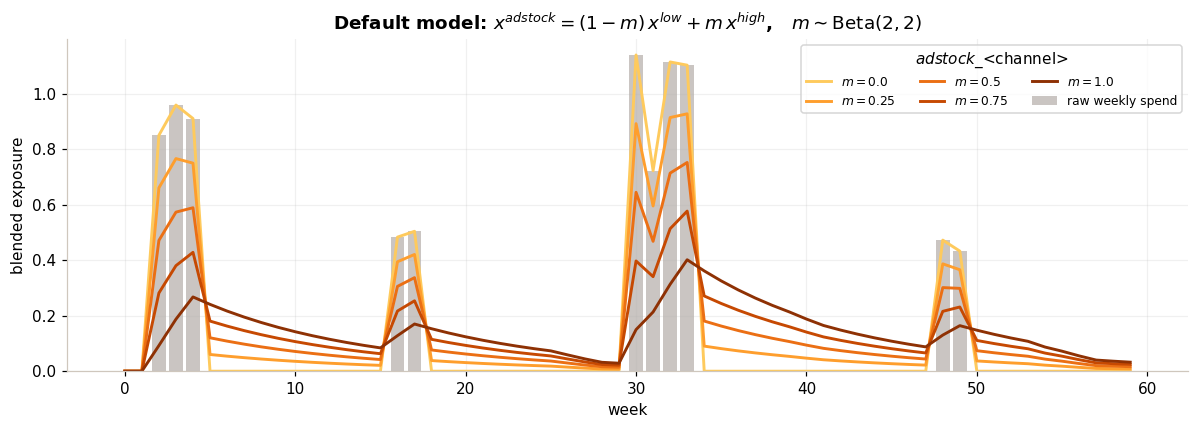

In [12]:
# Reproduce the DEFAULT mechanism exactly: blend two fixed-alpha geometric adstocks.
# These are the framework's default endpoints: adstock_alphas[0]=0.0, [-1]=0.9.
alpha_low, alpha_high = 0.0, 0.9
x_low = parametric_adstock(spend, "geometric", 24, alpha=alpha_low, normalize=True)
x_high = parametric_adstock(spend, "geometric", 24, alpha=alpha_high, normalize=True)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(np.arange(T), spend, color=MUTED, alpha=0.45, label="raw weekly spend")
mixes = [0.0, 0.25, 0.5, 0.75, 1.0]
greens = plt.cm.YlOrBr(np.linspace(0.35, 0.9, len(mixes)))
for m, col in zip(mixes, greens):
    x_blend = (1 - m) * x_low + m * x_high   # the literal model formula
    ax.plot(np.arange(T), x_blend, color=col, lw=1.9, label=rf"$m={m}$")
ax.set_xlabel("week"); ax.set_ylabel("blended exposure")
ax.set_title(r"Default model: $x^{adstock}=(1-m)\,x^{low}+m\,x^{high}$,   $m\sim\mathrm{Beta}(2,2)$")
ax.legend(title=r"$adstock\_$<channel>", ncol=3, loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

In [13]:
# VERIFY (d): the blend is a convex combination and the endpoints reproduce the
# fixed-alpha series exactly -- so m is a MIX WEIGHT, not a decay rate.
assert np.allclose((1 - 0.0) * x_low + 0.0 * x_high, x_low)   # m=0 -> low-memory series
assert np.allclose((1 - 1.0) * x_low + 1.0 * x_high, x_high)  # m=1 -> high-memory series
m = 0.5
blend = (1 - m) * x_low + m * x_high
assert np.all(blend <= np.maximum(x_low, x_high) + 1e-12)
assert np.all(blend >= np.minimum(x_low, x_high) - 1e-12)     # stays between the two
print("✓ m=0 recovers the low-alpha series; m=1 recovers the high-alpha series")
print("✓ any m in (0,1) is a convex blend bounded by the two endpoints")
print("   -> 'adstock_<CHANNEL>' = Beta(2,2) MIX WEIGHT, not a decay rate.")

✓ m=0 recovers the low-alpha series; m=1 recovers the high-alpha series
✓ any m in (0,1) is a convex blend bounded by the two endpoints
   -> 'adstock_<CHANNEL>' = Beta(2,2) MIX WEIGHT, not a decay rate.


## Identifiability: why decay and saturation fight each other

The framework's own `adstock_weights` docstring flags this, and it matters more than any single
formula. In an additive MMM each channel contributes

$$
\text{contribution}_t \;=\; \beta \cdot f_{\text{sat}}\!\big(\text{adstock}_\alpha(x)_t\big),
$$

and with a **normalized** kernel (weights summing to $1$) the carryover *magnitude* lives entirely in
$\beta$. That leaves **three knobs — decay shape, saturation strength, and $\beta$ — competing to
explain the same wiggle in the data.** A *long-carryover + weak-saturation* fit and a *short-carryover
+ strong-saturation* fit can be **nearly indistinguishable in-sample**. This is **equifinality**: it is
inherent to additive MMM, not a bug.

The plot below makes it concrete — two genuinely different settings produce almost the same effective
exposure path, so the likelihood can barely tell them apart from observational data alone.

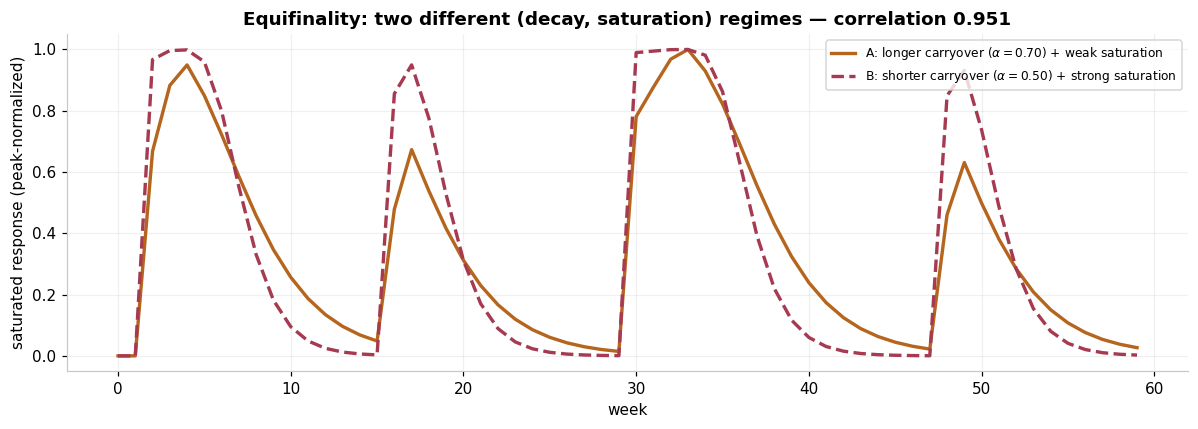

shape correlation between regimes A and B: 0.9509


In [14]:
from mmm_framework.transforms.saturation import logistic_saturation

# Two regimes that look almost identical AFTER adstock+saturation:
#  A) longer carryover (alpha high) + weak saturation
#  B) shorter carryover (alpha low) + strong saturation
xa = parametric_adstock(spend, "geometric", 24, alpha=0.70, normalize=True)
xb = parametric_adstock(spend, "geometric", 24, alpha=0.50, normalize=True)

# Pick saturation strengths so the two responses nearly coincide.
yA = logistic_saturation(xa, lam=4.0)   # weak saturation on longer-memory exposure
yB = logistic_saturation(xb, lam=8.0)   # strong saturation on shorter-memory exposure
# Rescale each to unit peak (beta would absorb this) to compare *shapes*.
yA = yA / yA.max(); yB = yB / yB.max()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(np.arange(T), yA, color=ACCENT, lw=2.2,
        label=r"A: longer carryover ($\alpha=0.70$) + weak saturation")
ax.plot(np.arange(T), yB, color=PALETTE["berry"], lw=2.2, ls="--",
        label=r"B: shorter carryover ($\alpha=0.50$) + strong saturation")
ax.set_xlabel("week"); ax.set_ylabel("saturated response (peak-normalized)")
corr = np.corrcoef(yA, yB)[0, 1]
ax.set_title(f"Equifinality: two different (decay, saturation) regimes — correlation {corr:.3f}")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()
print(f"shape correlation between regimes A and B: {corr:.4f}")

The two curves track each other at $\approx 0.95$ correlation despite **noticeably different** decay
rates ($\alpha = 0.70$ vs $0.50$), because the stronger saturation on the short-memory channel mimics
the smoothing the long-memory channel gets for free. With only observational data the per-channel decay
and saturation parameters are therefore **weakly identified**. The framework's recommended mitigations:

- **Informative priors** on $\alpha$ / saturation (don't let them roam to the boundary).
- **Anchoring saturation** to data percentiles (e.g. `SaturationConfig.compute_kappa_bounds_from_data`
  for the Hill path), so the half-saturation point is tied to observed spend levels.
- **Experiment-calibrated coefficient priors** (`mmm_framework.calibration`) — the most powerful fix.
  A geo-lift test pins $\beta$ directly, which **breaks the trade-off**: once the magnitude is nailed
  down by randomized evidence, the decay/saturation split is far better determined.

This is the bridge to the calibration notebook (`math_05_calibration.ipynb`).

## Recap & what's next

**The three representations, reconciled:**

| Form | Equation | Weight sum | Estimated knob |
|---|---|---|---|
| (a) IIR recurrence | $y_t = x_t + \alpha y_{t-1}$ | $1/(1-\alpha)$ | fixed $\alpha$ |
| (b) FIR kernel, `normalize=False` | $y_t=\sum_k \alpha^k x_{t-k}$ | $1/(1-\alpha)$ | fixed shape |
| (b) FIR kernel, `normalize=True` | $y_t=\sum_k \tilde w_k x_{t-k}$ | $1$ (mag $\to \beta$) | fixed shape |
| (c) PyTensor mirror | same as (b) | per `normalize` | **learned** $\alpha,\theta,s,\lambda$ |
| (d) default model blend | $(1-m)x^{\text{low}}+m\,x^{\text{high}}$ | — | **learned mix** $m$ |

**The two things people get wrong:**
1. Geometric adstock weights are **un-normalized** ($\sum = 1/(1-\alpha)$) unless you normalize; the
   normalized FIR kernel pushes that magnitude into $\beta$.
2. The default model's `adstock_<CHANNEL>` is a **Beta(2,2) blend weight** between two fixed-$\alpha$
   geometric adstocks — **not** a decay rate. Switch to `use_parametric_adstock=True` to estimate the
   actual kernel shape.

**Next in the math series:**
- **`math_02_saturation.ipynb`** — the *other* nonlinearity: diminishing returns (logistic / Hill),
  the curve that adstock feeds into and that fights it for identifiability.
- **`math_04_*.ipynb`** — putting adstock + saturation + $\beta$ together into the channel response and
  contribution decomposition.
- **`math_05_calibration.ipynb`** — how experiment-calibrated priors pin $\beta$ and **break** the
  equifinality we just demonstrated.